# Marfan project
by Chloé Laignel-Granier

## Step 1 : Upload the Excel data to Python

In [1]:
# Import the database and check its structure.
import pandas as pd
import numpy as np
file_path = "data/Marfan.xlsx"
data = pd.read_excel(file_path)
# Check data structure
print(data.head())
print(data.info())


   ID        age sexe  weight_kg  height_cm  BMI_kg_cm2  \
0   1  10.529774    M       47.8      162.6   18.079517   
1   2  14.351814    F       43.0      174.0   14.202669   
2   3  10.704997    M       26.0      142.0   12.894267   
3   4  17.393566    F       69.0      185.5   20.052165   
4   5  18.986995    F       54.8      177.0   17.491781   

   6minWT_Distance_traveled_m_before  6minWT_Distance_traveled_m_after  \
0                                660                             737.0   
1                                598                               NaN   
2                                556                             618.0   
3                                588                             692.0   
4                                583                               NaN   

   VO2_SV1__percent_theoretical_before  VO2_SV1__percent_theoretical_after  \
0                            29.918262                           39.958707   
1                            38.742243      

In [2]:
# Total number of patients
len(data)

28

## Step 2 : Clean data

In [3]:
# Rename columns for clarity
data = data.rename(columns={
    "VO2_SV1__percent_theoretical_after": "VAT_after",
    "VO2_SV1__percent_theoretical_before": "VAT_before"
})

In [4]:
# Standardize variable names
data.columns = data.columns.str.lower().str.strip()
data.head()

,id,age,sexe,weight_kg,height_cm,bmi_kg_cm2,6minwt_distance_traveled_m_before,6minwt_distance_traveled_m_after,vat_before,vat_after,pedsql_totalself_before,pedsql_totalself_after
0,1,10.529774,M,47.8,162.6,18.079517,660,737.0,29.918262,39.958707,69.565217,75.000000
1,2,14.351814,F,43.0,174.0,14.202669,598,NaN,38.742243,NaN,86.956522,NaN
2,3,10.704997,M,26.0,142.0,12.894267,556,618.0,38.237739,41.531482,92.391304,92.391304
3,4,17.393566,F,69.0,185.5,20.052165,588,692.0,28.950695,45.052754,52.173913,57.608696
4,5,18.986995,F,54.8,177.0,17.491781,583,NaN,39.959155,NaN,76.086957,70.652174


In [5]:
# Check that the pandas recognize the NaN
print(data.isna().sum())

id                                   0
age                                  0
sexe                                 0
weight_kg                            0
height_cm                            0
bmi_kg_cm2                           0
6minwt_distance_traveled_m_before    0
6minwt_distance_traveled_m_after     8
vat_before                           0
vat_after                            8
pedsql_totalself_before              0
pedsql_totalself_after               6
dtype: int64


## Step 3—Separate the analyzed and excluded patients

In [6]:
# Before + after columns
cols_all = [
    "6minwt_distance_traveled_m_before",
    "6minwt_distance_traveled_m_after",
    "vat_before",
    "vat_after",
    "pedsql_totalself_before",
    "pedsql_totalself_after"
]

# Analysable patients (no missing data)
data_inclus = data.dropna(subset=cols_all)

# Excluded patients (at least one missing piece of data)
data_exclus = data[data[cols_all].isna().any(axis=1)]

# Verification
print("Total patients :", len(data))
print("Inclus :", len(data_inclus))
print("Exclus :", len(data_exclus))

# Check the excluded patients
print(data_exclus[cols_all])

Total patients : 28
Inclus : 20
Exclus : 8
    6minwt_distance_traveled_m_before  6minwt_distance_traveled_m_after  \
1                                 598                               NaN   
4                                 583                               NaN   
6                                 635                               NaN   
11                                634                               NaN   
15                                593                               NaN   
16                                568                               NaN   
24                                580                               NaN   
26                                588                               NaN   

    vat_before  vat_after  pedsql_totalself_before  pedsql_totalself_after  
1    38.742243        NaN                86.956522                     NaN  
4    39.959155        NaN                76.086957               70.652174  
6    32.164149        NaN                75.000000

## Step 4 : Transformation to Long Format

In [7]:
# Transform the data to long format for distance traveled
distance_long = pd.melt(
    data_inclus,
    id_vars=["id"],
    value_vars=["6minwt_distance_traveled_m_before","6minwt_distance_traveled_m_after"],
    var_name="time",
    value_name="distance"
)

# Simplify the time variable
distance_long["time"] = distance_long["time"].map({
     "6minwt_distance_traveled_m_before": "T-3",
     "6minwt_distance_traveled_m_after": "T+6"
 })
print(distance_long)

    id time  distance
0    1  T-3     660.0
1    3  T-3     556.0
2    4  T-3     588.0
3    6  T-3     635.0
4    8  T-3     640.0
5    9  T-3     593.0
6   10  T-3     551.0
7   11  T-3     516.0
8   13  T-3     625.0
9   14  T-3     526.0
10  15  T-3     608.0
11  18  T-3     620.0
12  19  T-3     495.0
13  20  T-3     650.0
14  21  T-3     580.0
15  22  T-3     560.0
16  23  T-3     450.0
17  24  T-3     560.0
18  26  T-3     535.0
19  28  T-3     600.0
20   1  T+6     737.0
21   3  T+6     618.0
22   4  T+6     692.0
23   6  T+6     697.0
24   8  T+6     598.0
25   9  T+6     682.0
26  10  T+6     744.0
27  11  T+6     682.0
28  13  T+6     575.0
29  14  T+6     585.0
30  15  T+6     605.0
31  18  T+6     615.0
32  19  T+6     490.0
33  20  T+6     725.0
34  21  T+6     540.0
35  22  T+6     625.0
36  23  T+6     460.0
37  24  T+6     530.0
38  26  T+6     590.0
39  28  T+6     595.0


## Step 5 : Calculating differences

In [8]:
data_inclus["delta_6mwt"] = data_inclus["6minwt_distance_traveled_m_after"] - data_inclus["6minwt_distance_traveled_m_before"]
print(data_inclus[["id", "delta_6mwt"]])

    id  delta_6mwt
0    1        77.0
2    3        62.0
3    4       104.0
5    6        62.0
7    8       -42.0
8    9        89.0
9   10       193.0
10  11       166.0
12  13       -50.0
13  14        59.0
14  15        -3.0
17  18        -5.0
18  19        -5.0
19  20        75.0
20  21       -40.0
21  22        65.0
22  23        10.0
23  24       -30.0
25  26        55.0
27  28        -5.0


## Step 6: Data visualization

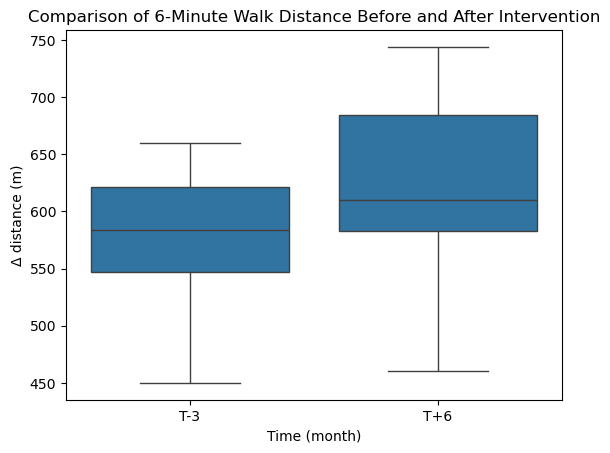

In [12]:
# Boxplot of distance traveled before and after
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=distance_long, x="time", y="distance")

plt.title("Comparison of 6-Minute Walk Distance Before and After Intervention")
plt.xlabel("Time (month)")
plt.ylabel("Δ distance (m)")
plt.show()

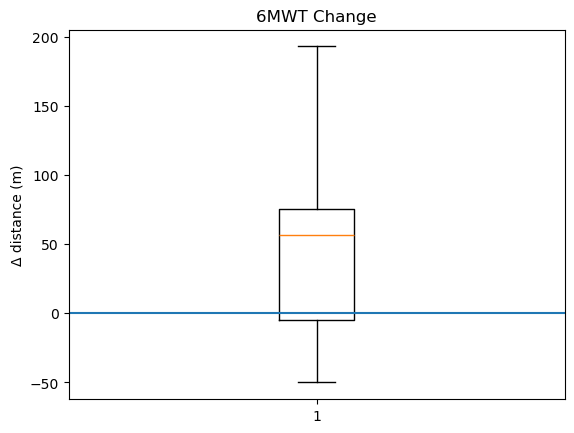

In [ ]:
# Boxplot of the delta distance traveled
plt.boxplot(data_inclus["delta_6mwt"])
plt.axhline(0)  # reference line at 0
plt.title("Individual Changes in 6-Minute Walk Distance Following Intervention")
plt.xlabel("Patients")
plt.ylabel("Δ distance (m)")
plt.show()